# Prepare the features

- BOP features arrangement and averagings
- Library Features arrangement ad averaging
- Matminer features cleanup (decide min, max or avg)
- clear feature list from correlations
- outlier detection based on features
- Feature Distribution plots

 - input : features dataframes from prev steps
 - output: clean features dataframes into picles

In [1]:
import pandas as pd
import seaborn
import matplotlib.pyplot as plt
import copy
import os
import numpy as np
import pdb
from tqdm.auto import tqdm 
from Tools.DatasetTools import GeneralFeaturizer as gf
dataset = 'Cr-Co-W/'
descriptorlocation = os.path.join(dataset, 'Descriptors')

import pdb

# Load Features 

In [2]:
PyscalFeaturesFile = os.path.join(descriptorlocation, 'pyscal_steinhardt.kpl')
BopFeaturesFile = os.path.join(descriptorlocation, 'CrCoW_initial_canonical_table_WUBIND_16.pkl')
AtomicFeaturesFile = os.path.join(descriptorlocation, 'matminer_atomic_features.pkl')
CompositionFeaturesFile = os.path.join(descriptorlocation, 'matminer_composition_features.pkl')

PyscalFeatures = pd.read_pickle(PyscalFeaturesFile)
BopFeatures = pd.read_pickle(BopFeaturesFile)
AtomicFeatures = pd.read_pickle(AtomicFeaturesFile)
CompositionFeatures = pd.read_pickle(CompositionFeaturesFile)

# Arrangement and averaging BOP Features 

In [3]:
BopFeatures

,U_bind,U_bond_atom,U_bond_atom_list,moments,normed_moments,an,bn,sigma,Ainf,Binf
Co_pv6W_sv6.C14-BBA.FM,-58.644616,-78.588438,"[-4.3975143698, -4.3975143698, -4.3975143698, ...","[[0.0, 1.30409, -0.634205, 4.08953, -4.29737, ...","[[0.0717862986, 0.0843546428, 0.0079343959, 0....","[[0.0, -0.48632200000000003, -0.22576999999999...","[[0.0, 1.14197, 1.26307, 1.51045, 1.71511, 1.7...","[[1.0, 0.143370955, -0.6601173127, -0.22212161...","[-0.2912918773, -0.2912918773, -0.2912918773, ...","[2.0288821321, 2.0288821321, 2.0288821321, 2.0..."
Co_pv6W_sv6.C14-BBA.NM,-58.644616,-78.588438,"[-4.3975143698, -4.3975143698, -4.3975143698, ...","[[0.0, 1.30409, -0.634205, 4.08953, -4.29737, ...","[[0.0717862986, 0.0843546428, 0.0079343959, 0....","[[0.0, -0.48632200000000003, -0.22576999999999...","[[0.0, 1.14197, 1.26307, 1.51045, 1.71511, 1.7...","[[1.0, 0.143370955, -0.6601173127, -0.22212161...","[-0.2912918773, -0.2912918773, -0.2912918773, ...","[2.0288821321, 2.0288821321, 2.0288821321, 2.0..."
Cr_pv6W_sv2.D0_19-A3B.FM,-42.039279,-42.05443,"[-5.3205290305, -5.3211668379, -5.3205290069, ...","[[0.0, 1.55611, -0.46190499999999995, 4.3839, ...","[[0.1014238266, 0.2121465775, 0.0408827474, 0....","[[0.0, -0.296833, -0.469329, -0.400833, -0.563...","[[0.0, 1.24744, 1.08305, 1.15153, 1.18244, 1.2...","[[1.0, 0.2025627613, -0.1508505882, -0.0780889...","[-0.2816017388, -0.2816017668, -0.2816209469, ...","[1.3882425276, 1.3882425434, 1.3883516161, 1.3..."
Cr_pv6W_sv2.D0_19-A3B.NM,-42.039279,-42.05443,"[-5.3205290305, -5.3211668379, -5.3205290069, ...","[[0.0, 1.55611, -0.46190499999999995, 4.3839, ...","[[0.1014238266, 0.2121465775, 0.0408827474, 0....","[[0.0, -0.296833, -0.469329, -0.400833, -0.563...","[[0.0, 1.24744, 1.08305, 1.15153, 1.18244, 1.2...","[[1.0, 0.2025627613, -0.1508505882, -0.0780889...","[-0.2816017388, -0.2816017668, -0.2816209469, ...","[1.3882425276, 1.3882425434, 1.3883516161, 1.3..."
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,-143.858275,-177.797933,"[-5.6783573351, -5.6783573351, -5.6783573351, ...","[[0.0, 1.6417299999999997, -0.514678, 4.64595,...","[[0.0511669029, 0.1742224999, 0.0090822449, 0....","[[0.0, -0.313498, -0.0932309, -0.316523, -0.13...","[[0.0, 1.2813, 1.04399, 1.22413, 1.20185, 1.29...","[[1.0, 0.10219008189999998, -0.3019827453, -0....","[-0.158261488, -0.158261488, -0.158261488, -0....","[1.5465220577, 1.5465220577, 1.5465220577, 1.5..."
...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,-73.831298,-74.435034,"[-6.9191485421, -6.919148542, -6.9191513819, -...","[[0.0, 2.32545, -0.791208, 9.27675, -7.1620900...","[[0.0938956088, 0.1856862941, 0.0340534405, 0....","[[0.0, -0.340239, -0.261418, -0.680929, -0.326...","[[0.0, 1.52494, 1.24419, 1.6427599999999998, 1...","[[1.0, 0.1875274718, -0.2562981024, -0.1024407...","[-0.3404644258, -0.1911202335, -0.1911202335, ...","[1.8129944001, 1.7889585488, 1.7889585488, 1.7..."
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,-156.777732,-172.917606,"[-5.0627343795, -5.0627343795, -5.0627343795, ...","[[0.0, 1.34753, -0.454488, 3.32921, -2.3634, 1...","[[0.0464940682, 0.1540991271, 0.0040858193, 0....","[[0.0, -0.337275, -0.124542, -0.254523, -0.055...","[[0.0, 1.16083, 1.00465, 1.17859, 1.15633, 1.2...","[[1.0, 0.0928575381, -0.3821768843, -0.1522285...","[-0.1384632371, -0.1384632371, -0.1384632371, ...","[1.4890419619, 1.4890419619, 1.4890419619, 1.4..."
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,-156.777732,-172.917606,"[-5.0627343795, -5.0627343795, -5.0627343795, ...","[[0.0, 1.34753, -0.454488, 3.32921, -2.3634, 1...","[[0.0464940682, 0.1540991271, 0.0040858193, 0....","[[0.0, -0.337275, -0.124542, -0.254523, -0.055...","[[0.0, 1.16083, 1.00465, 1.17859, 1.15633, 1.2...","[[1.0, 0.0928575381, -0.3821768843, -0.1522285...","[-0.1384632371, -0.1384632371, -0.1384632371, ...","[1.4890419619, 1.4890419619, 1.4890419619, 1.4..."
Co_pv13W_sv16.chi-ABAB.NM,-127.090687,-186.802107,"[-5.1432538134, -5.1432538134, -5.1432538134, ...","[[0.0, 1.39375, -0.697376, 4.37561, -4.

In [4]:
columnstoexpand = BopFeatures.columns.drop(['U_bind','U_bond_atom', 'U_bond_atom_list'])
columnstoexpand

Index(['moments', 'normed_moments', 'an', 'bn', 'sigma', 'Ainf', 'Binf'], dtype='object')

In [5]:
df = gf.array_expansions(BopFeatures, columnstoexpand)

In [6]:
BOPAveraged = gf.cnaverage_dataframe(df, df.columns, PyscalFeatures.pyscal_cn[df.index],)

  0%|          | 0/77 [00:00<?, ?it/s]

In [7]:
gf.cnav_column_name_fix(BOPAveraged)

In [8]:
BOPAveraged = pd.concat(BOPAveraged.values(), axis=1)

In [9]:
BOPAveraged

,moments_1_0,moments_1_CN12,moments_1_CN14,moments_1_CN15,moments_1_CN16,moments_2_0,moments_2_CN12,moments_2_CN14,moments_2_CN15,moments_2_CN16,...,sigma_14_0,sigma_14_CN12,sigma_14_CN14,sigma_14_CN15,sigma_14_CN16,sigma_15_0,sigma_15_CN12,sigma_15_CN14,sigma_15_CN15,sigma_15_CN16
Co_pv6W_sv6.C14-BBA.FM,2.496405,2.061708,0.000000,0.000000,0.434697,-0.957307,-0.745905,0.000000,0.000000,-0.211402,...,-0.098835,-0.088005,0.000000,0.000000,-0.010830,-0.009289,-0.005191,0.000000,0.000000,-0.004098
Co_pv6W_sv6.C14-BBA.NM,2.496405,2.061708,0.000000,0.000000,0.434697,-0.957307,-0.745905,0.000000,0.000000,-0.211402,...,-0.098835,-0.088005,0.000000,0.000000,-0.010830,-0.009289,-0.005191,0.000000,0.000000,-0.004098
Cr_pv6W_sv2.D0_19-A3B.FM,1.530625,1.530625,0.000000,0.000000,0.000000,-0.453207,-0.453207,0.000000,0.000000,0.000000,...,0.019260,0.019260,0.000000,0.000000,0.000000,0.029418,0.029418,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,1.530625,1.530625,0.000000,0.000000,0.000000,-0.453207,-0.453207,0.000000,0.000000,0.000000,...,0.019260,0.019260,0.000000,0.000000,0.000000,0.029418,0.029418,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,1.797828,0.663849,0.945488,0.188491,0.000000,-0.577710,-0.213980,-0.298615,-0.065115,0.000000,...,0.033443,0.006701,0.024923,0.001819,0.000000,-0.000806,0.004524,-0.003515,-0.001815,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,1.828545,1.308482,0.197531,0.143759,0.178772,-0.599148,-0.426060,-0.055556,-0.040615,-0.076917,...,-0.047778,-0.047196,-0.000755,0.007952,-0.007779,-0.015776,-0.013269,-0.009275,0.008601,-0.001832
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,1.713707,0.632789,0.901248,0.179671,0.000000,-0.537641,-0.199138,-0.277904,-0.060598,0.000000,...,0.033443,0.006701,0.024923,0.001819,0.000000,-0.000806,0.004524,-0.003515,-0.001815,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,1.713707,0.632789,0.901248,0.179671,0.000000,-0.537641,-0.199138,-0.277904,-0.060598,0.000000,...,0.033443,0.006701,0.024923,0.001819,0.000000,-0.000806,0.004524,-0.003515,-0.001815,0.000000
Co_pv13W_sv16.chi-ABAB.NM,2.241933,0.000000,0.000000,0.000000,0.266543,-0.751986,0.000000,0.000000,0.000000,-0.120221,...,-0.018872,0.000000,0.000000,0.000000,-0.020892,0.048321,0.000000,0.000000,0.000000,0.002148


In [10]:
averaged_bop_file = os.path.join(descriptorlocation,'CNAV_'+os.path.basename(BopFeaturesFile))

In [11]:
BOPAveraged.to_pickle(averaged_bop_file)

## Averaging Pyscal Features

In [12]:
columnstoexpand = [col for col in PyscalFeatures if 'steinhardt' in col]

In [13]:
PyscalFeaturesAveraged = gf.cnaverage_dataframe(PyscalFeatures, columnstoexpand, PyscalFeatures.pyscal_cn)

  0%|          | 0/2 [00:00<?, ?it/s]

In [14]:
gf.cnav_column_name_fix(PyscalFeaturesAveraged)

In [15]:
PyscalFeaturesAveraged = pd.concat(PyscalFeaturesAveraged.values(), axis = 1)

In [16]:
PyscalFeaturesAveraged.to_pickle(os.path.join(descriptorlocation,f'CNAV_{os.path.basename(PyscalFeaturesFile)}'))

In [17]:
PyscalFeaturesAveraged

,pyscal_steinhardt_0_0,pyscal_steinhardt_0_CN12,pyscal_steinhardt_0_CN14,pyscal_steinhardt_0_CN15,pyscal_steinhardt_0_CN16,pyscal_steinhardt_1_0,pyscal_steinhardt_1_CN12,pyscal_steinhardt_1_CN14,pyscal_steinhardt_1_CN15,pyscal_steinhardt_1_CN16
Co_pv6W_sv6.C14-BBA.FM,0.021754,0.020735,0.000000,0.000000,0.001019,0.500586,0.436126,0.000000,0.000000,0.064460
Co_pv6W_sv6.C14-BBA.NM,0.021754,0.020735,0.000000,0.000000,0.001019,0.500586,0.436126,0.000000,0.000000,0.064460
Cr_pv6W_sv2.D0_19-A3B.FM,0.089643,0.089643,0.000000,0.000000,0.000000,0.482020,0.482020,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,0.089643,0.089643,0.000000,0.000000,0.000000,0.482020,0.482020,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,0.063293,0.037974,0.022234,0.003085,0.000000,0.469031,0.209215,0.217703,0.042113,0.000000
...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,0.043541,0.036474,0.004550,0.000248,0.002268,0.478648,0.340808,0.061350,0.045118,0.031371
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,0.063293,0.037974,0.022234,0.003085,0.000000,0.469031,0.209215,0.217703,0.042113,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,0.063293,0.037974,0.022234,0.003085,0.000000,0.469031,0.209215,0.217703,0.042113,0.000000
Co_pv13W_sv16.chi-ABAB.NM,0.081875,0.000000,0.000000,0.000000,0.005151,0.471315,0.000000,0.000000,0.000000,0.033856


# compiling FULL features 

In [19]:
AllFeatures = [AtomicFeatures, CompositionFeatures, BOPAveraged, PyscalFeaturesAveraged]

In [20]:
FullSetOfFeatures = pd.concat(AllFeatures, axis = 1)

In [21]:
FullSetOfFeatures

,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,...,pyscal_steinhardt_0_0,pyscal_steinhardt_0_CN12,pyscal_steinhardt_0_CN14,pyscal_steinhardt_0_CN15,pyscal_steinhardt_0_CN16,pyscal_steinhardt_1_0,pyscal_steinhardt_1_CN12,pyscal_steinhardt_1_CN14,pyscal_steinhardt_1_CN15,pyscal_steinhardt_1_CN16
Co_pv6W_sv6.C14-BBA.FM,27.0,74.0,47.0,69.727273,7.768595,74.0,51.0,58.0,7.0,51.636364,...,0.021754,0.020735,0.000000,0.000000,0.001019,0.500586,0.436126,0.000000,0.000000,0.064460
Co_pv6W_sv6.C14-BBA.NM,27.0,74.0,47.0,69.727273,7.768595,74.0,51.0,58.0,7.0,51.636364,...,0.021754,0.020735,0.000000,0.000000,0.001019,0.500586,0.436126,0.000000,0.000000,0.064460
Cr_pv6W_sv2.D0_19-A3B.FM,24.0,74.0,50.0,62.461538,17.751479,74.0,49.0,51.0,2.0,50.538462,...,0.089643,0.089643,0.000000,0.000000,0.000000,0.482020,0.482020,0.000000,0.000000,0.000000
Cr_pv6W_sv2.D0_19-A3B.NM,24.0,74.0,50.0,62.461538,17.751479,74.0,49.0,51.0,2.0,50.538462,...,0.089643,0.089643,0.000000,0.000000,0.000000,0.482020,0.482020,0.000000,0.000000,0.000000
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,24.0,74.0,50.0,41.066667,21.955556,24.0,49.0,58.0,9.0,50.866667,...,0.063293,0.037974,0.022234,0.003085,0.000000,0.469031,0.209215,0.217703,0.042113,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv10W_sv3.mu-BAAAB.FM,24.0,74.0,50.0,61.500000,18.750000,74.0,49.0,51.0,2.0,50.500000,...,0.043541,0.036474,0.004550,0.000248,0.002268,0.478648,0.340808,0.061350,0.045118,0.031371
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,24.0,74.0,50.0,37.533333,19.448889,24.0,49.0,58.0,9.0,50.133333,...,0.063293,0.037974,0.022234,0.003085,0.000000,0.469031,0.209215,0.217703,0.042113,0.000000
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,24.0,74.0,50.0,37.533333,19.448889,24.0,49.0,58.0,9.0,50.133333,...,0.063293,0.037974,0.022234,0.003085,0.000000,0.469031,0.209215,0.217703,0.042113,0.000000
Co_pv13W_sv16.chi-ABAB.NM,27.0,74.0,47.0,70.468208,6.532794,74.0,51.0,58.0,7.0,51.526012,...,0.081875,0.000000,0.000000,0.000000,0.005151,0.471315,0.000000,0.000000,0.000000,0.033856


#  Correlation of Features

In [33]:
CORR = FullSetOfFeatures.corr().abs()

to facilitate higly correlations removal, I will see only the upper triangle of this simmetric matrix

In [35]:
tri_upper_corr = CORR.where(np.triu(np.ones(CORR.shape), k=1).astype(bool))

<AxesSubplot:>

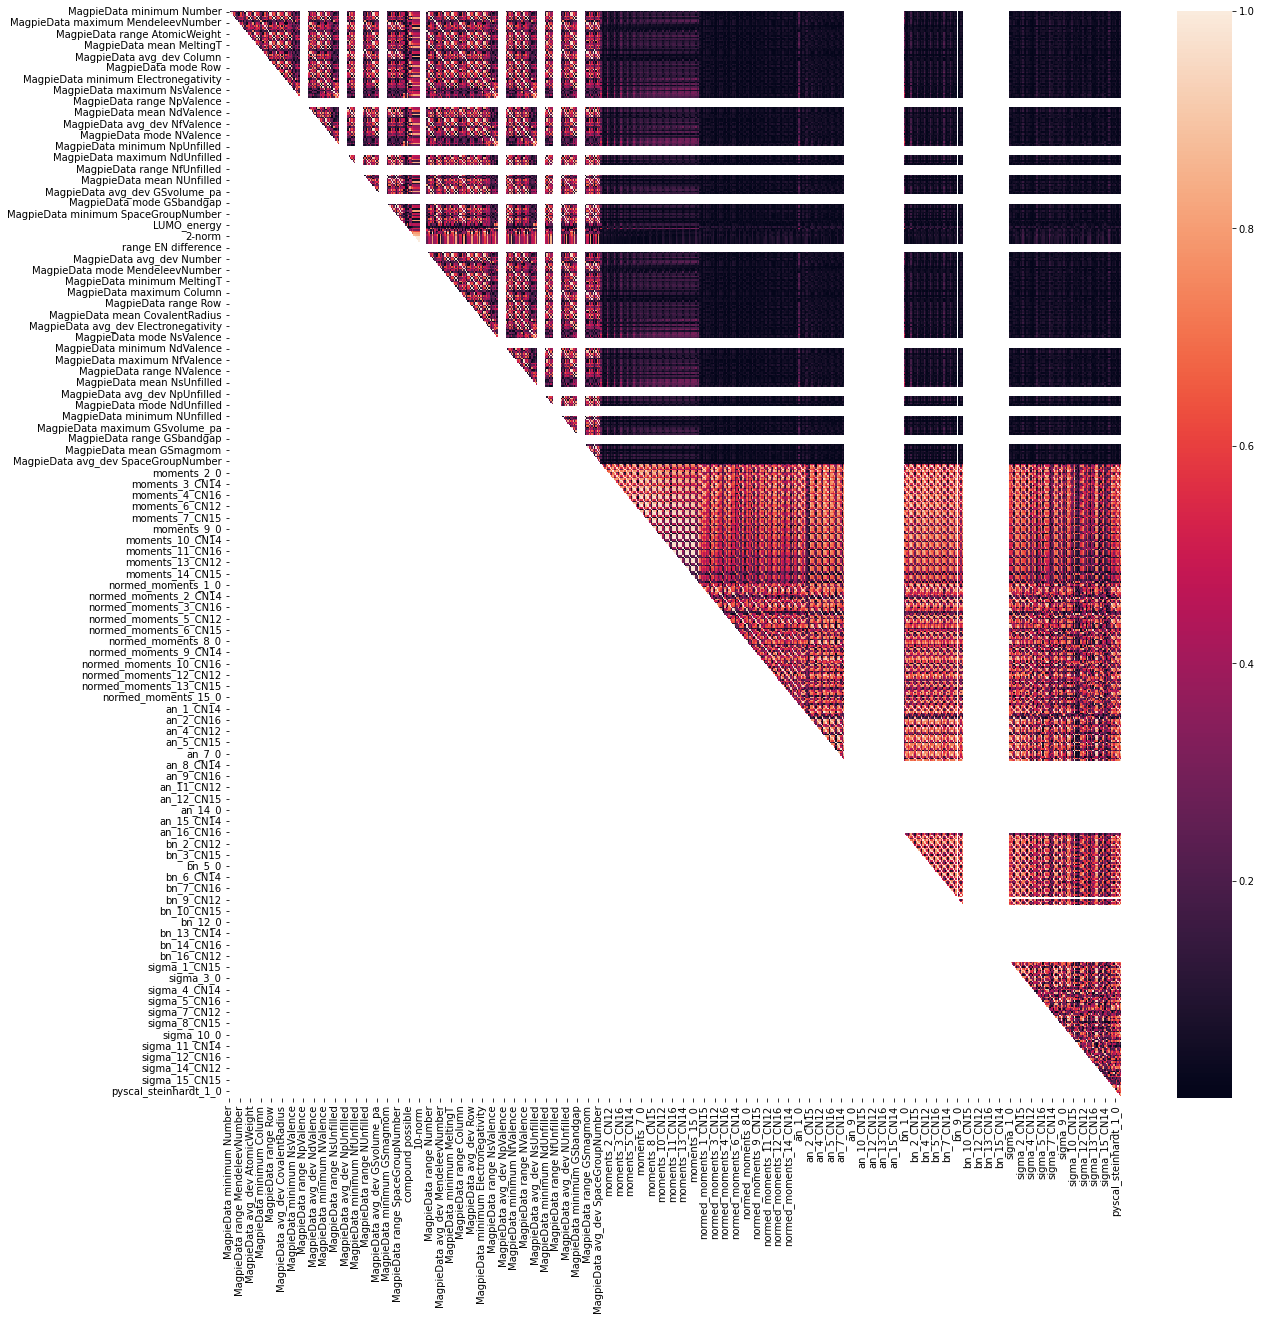

In [36]:
fig, ax = plt.subplots(figsize =(20,20))

seaborn.heatmap(tri_upper_corr, ax = ax)

In [27]:
CORR.describe()

,MagpieData minimum Number,MagpieData maximum Number,MagpieData range Number,MagpieData mean Number,MagpieData avg_dev Number,MagpieData mode Number,MagpieData minimum MendeleevNumber,MagpieData maximum MendeleevNumber,MagpieData range MendeleevNumber,MagpieData mean MendeleevNumber,...,pyscal_steinhardt_0_0,pyscal_steinhardt_0_CN12,pyscal_steinhardt_0_CN14,pyscal_steinhardt_0_CN15,pyscal_steinhardt_0_CN16,pyscal_steinhardt_1_0,pyscal_steinhardt_1_CN12,pyscal_steinhardt_1_CN14,pyscal_steinhardt_1_CN15,pyscal_steinhardt_1_CN16
count,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,...,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000
mean,0.017792,0.123987,0.115473,0.076511,0.099098,0.069017,-0.008004,0.018015,0.020444,-0.068694,...,-0.007625,0.014371,0.017288,0.024229,-0.024269,-0.006512,0.011080,0.017539,0.024427,-0.013159
std,0.212486,0.329261,0.329227,0.358966,0.297122,0.326225,0.223339,0.316258,0.332971,0.321812,...,0.342226,0.217052,0.474554,0.448233,0.375850,0.418545,0.436527,0.474938,0.412003,0.515189
min,-0.434474,-0.898208,-0.866922,-0.883749,-0.814197,-0.748174,-0.791377,-0.996833,-0.914362,-0.979627,...,-0.767861,-0.783559,-0.984908,-0.995963,-0.891159,-0.851798,-0.991644,-0.998094,-0.995760,-0.997224
25%,-0.071224,-0.039235,-0.046772,-0.057120,-0.057515,-0.043600,-0.100763,-0.070051,-0.075794,-0.109233,...,-0.149159,-0.080692,-0.264005,-0.231538,-0.196920,-0.238794,-0.158811,-0.246997,-0.164538,-0.238741
50%,0.005596,0.032013,0.028671,0.010762,0.042010,0.016583,-0.002949,-0.003138,0.010970,-0.005603,...,-0.032147,-0.002499,-0.002311,0.018551,0.000650,-0.012863,0.008819,-0.001355,0.048868,0.011314
75%,0.064255,0.214769,0.219132,0.194546,0.136804,0.149158,0.072659,0.096956,0.110385,0.030202,...,0.184244,0.127696,0.286114,0.282904,0.070794,0.238314,0.122847,0.276643,0.214565,0.165663
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
